In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(423)

# mRNA - mRNA Correlations

# Loading

In [3]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("TotalX_HEK293T_capture.txt")

In [4]:
# load miRNA MIR3655 results
ind_MF_df = pd.read_csv("Results/d3/ind_MF_12.csv", index_col=0)
int_MF_df = pd.read_csv("Results/d3/int_MF_12.csv", index_col=0)
BD_df = pd.read_csv("Results/d3/BD_12.csv", index_col=0)
TE_df = pd.read_csv("Results/d3/TE_12.csv", index_col=0)
corr_df = pd.read_csv("Results/corr_12.csv", index_col=0)

In [5]:
# compute HAR midpoint
lb = int_MF_df['MIR3655_d3_N1000_c95_mc95_HAR_corr_min']
ub = int_MF_df['MIR3655_d3_N1000_c95_mc95_HAR_corr_max']
mid = (lb + ub) / 2

In [ ]:
'''
simple way to subset using indices
but may lead to errors if size of result & adata not same
'''

# subset adata to interacting pcRNA
#mask_int = (ind_MF_df == "INFEASIBLE").values.squeeze()
#idxs_int = np.arange(len(mask_int))[mask_int]
#adata_int = adata_pcRNA[:, idxs_int]

# subset adata to independent pcRNA
#mask_ind = (ind_MF_df == "OPTIMAL").values.squeeze()
#idxs_ind = np.arange(len(mask_ind))[mask_ind]
#adata_ind = adata_pcRNA[:, idxs_ind]

In [ ]:
'''
can also subset using gene names and .var
should be safer as names always same
'''

# get names of interacting pcRNA
#mask_int = (ind_MF_df == "INFEASIBLE")
#names_int = mask_int.index[mask_int.values.squeeze()].tolist()

# get names of independent pcRNA
#mask_ind = (ind_MF_df == "OPTIMAL")
#names_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()

# subset adata
#adata_int = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_int)]
#adata_ind = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_ind)]

# Running

In [21]:
# size
M = 25

# get names of negatively correlated interacting pcRNA
names_neg = mid[mid < -0.25].index.tolist()
names_neg = rng.choice(names_neg, size=M, replace=False)

# get names of positively correlated interacting pcRNA
names_pos = mid[mid > 0.25].index.tolist()
names_pos = rng.choice(names_pos, size=M, replace=False)

# get names of independent pcRNA
mask_ind = (ind_MF_df == "OPTIMAL")
names_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()
names_ind = rng.choice(names_ind, size=M, replace=False)

# subset adata
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]
adata_pos = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_pos)]
adata_ind = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_ind)]

In [37]:
# compute correlations between all pairs of M genes: no repeats
Is, Js = np.triu_indices(M, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# construct datasets
data_neg = SDP_miRNA.dataset.Dataset()
data_pos = SDP_miRNA.dataset.Dataset()
data_ind = SDP_miRNA.dataset.Dataset()

data_neg.construct_dataset_adata(adata_neg, adata_neg, beta, gene_queries)
data_pos.construct_dataset_adata(adata_pos, adata_pos, beta, gene_queries)
data_ind.construct_dataset_adata(adata_ind, adata_ind, beta, gene_queries)

# bootstrap
data_neg.bootstrap(d=3)
data_pos.bootstrap(d=3)
data_ind.bootstrap(d=3)

100%|██████████| 3/3 [00:05<00:00,  1.78s/it]


In [76]:
# model free independence test
MF_ind_neg = SDP_miRNA.optimization.ModelFreeOptimization(data_neg, d=3)
MF_ind_pos = SDP_miRNA.optimization.ModelFreeOptimization(data_pos, d=3)
MF_ind_ind = SDP_miRNA.optimization.ModelFreeOptimization(data_ind, d=3)
MF_ind_neg.analyse_dataset()
MF_ind_pos.analyse_dataset()
MF_ind_ind.analyse_dataset()

100%|██████████| 300/300 [00:13<00:00, 21.78it/s]


In [77]:
# model free interacting H&R: should really subset queries to just interacting pairs, but small enough
MF_int_neg = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_neg, d=3)
MF_int_pos = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_pos, d=3)
MF_int_ind = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_ind, d=3)
MF_int_neg.analyse_dataset()
MF_int_pos.analyse_dataset()
MF_int_ind.analyse_dataset()

  7%|▋         | 20/300 [00:17<03:57,  1.18it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


100%|██████████| 300/300 [04:26<00:00,  1.13it/s]


In [78]:
# H&R correlations
HAR_points_neg, HAR_intervals_neg = MF_int_neg.compute_dataset_correlation()
HAR_points_pos, HAR_intervals_pos = MF_int_pos.compute_dataset_correlation()
HAR_points_ind, HAR_intervals_ind = MF_int_ind.compute_dataset_correlation()

  6%|▌         | 17/300 [00:00<00:08, 33.22it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
  9%|▉         | 27/300 [00:00<00:07, 38.90it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 300/300 [00:07<00:00, 40.81it/s]


In [80]:
# H&R midpoints
HAR_mid_neg = (HAR_intervals_neg[:, 0] + HAR_intervals_neg[:, 1]) / 2
HAR_mid_pos = (HAR_intervals_pos[:, 0] + HAR_intervals_pos[:, 1]) / 2
HAR_mid_ind = (HAR_intervals_ind[:, 0] + HAR_intervals_ind[:, 1]) / 2

In [79]:
# correlation
OB_neg, AL_neg = SDP_miRNA.correlation.compute_correlations(data_neg)
OB_pos, AL_pos = SDP_miRNA.correlation.compute_correlations(data_pos)
OB_ind, AL_ind = SDP_miRNA.correlation.compute_correlations(data_ind)

100%|██████████| 3/3 [00:03<00:00,  1.10s/it]


# Results

## Violin

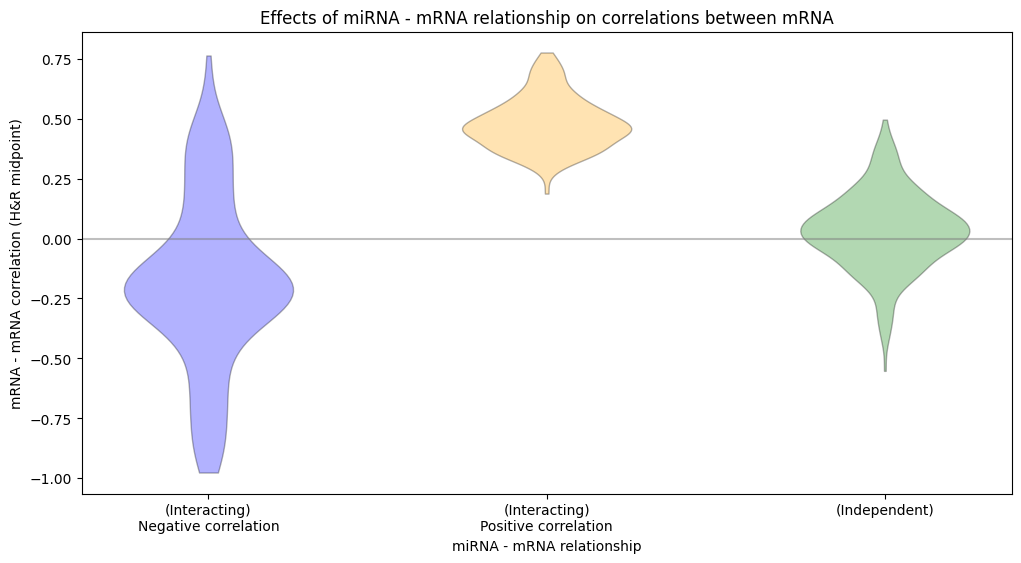

In [97]:
fig, axs = plt.subplots(figsize=(12, 6))
plot_data_list = [HAR_mid_neg[~np.isnan(HAR_mid_neg)], HAR_mid_pos, HAR_mid_ind]
plot_colors = ["blue", "orange", "green"]
plot_labels = ["A", "B", "C"]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="both"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1, 2])
axs.set_xticklabels(["(Interacting)\nNegative correlation", "(Interacting)\nPositive correlation", "(Independent)"])
axs.set_xlabel("miRNA - mRNA relationship")
axs.set_ylabel("mRNA - mRNA correlation (H&R midpoint)")
axs.set_title("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.show()

## Heatmap

In [109]:
from matplotlib.colors import LinearSegmentedColormap

In [113]:
corr_matrix_neg = np.zeros((M, M))
corr_matrix_pos = np.zeros((M, M))
corr_matrix_ind = np.zeros((M, M))
for i, query in enumerate(data_neg.gene_queries):
    if MF_ind_neg.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_neg[query[0][0], query[1][0]] = HAR_mid_neg[i]
for i, query in enumerate(data_pos.gene_queries):
    if MF_ind_pos.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_pos[query[0][0], query[1][0]] = HAR_mid_pos[i]
for i, query in enumerate(data_ind.gene_queries):
    if MF_ind_ind.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_ind[query[0][0], query[1][0]] = HAR_mid_ind[i]

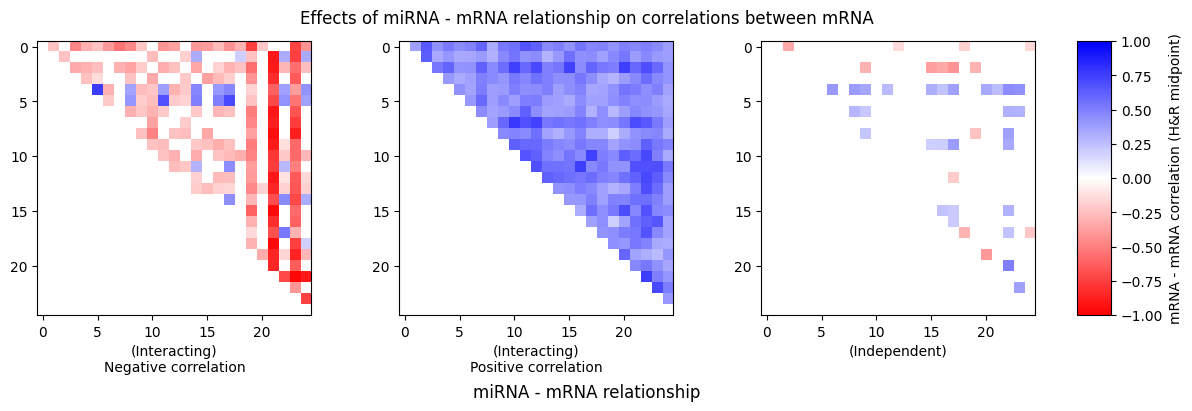

In [129]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 4, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(corr_matrix_neg, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(corr_matrix_pos, cmap=cmap, vmin=-1, vmax=1)
im = axs[2].imshow(corr_matrix_ind, cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("(Interacting)\nNegative correlation")
axs[1].set_xlabel("(Interacting)\nPositive correlation")
axs[2].set_xlabel("(Independent)")
fig.supxlabel("miRNA - mRNA relationship")
fig.suptitle("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.colorbar(im, cax=axs[3], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

## Scatter

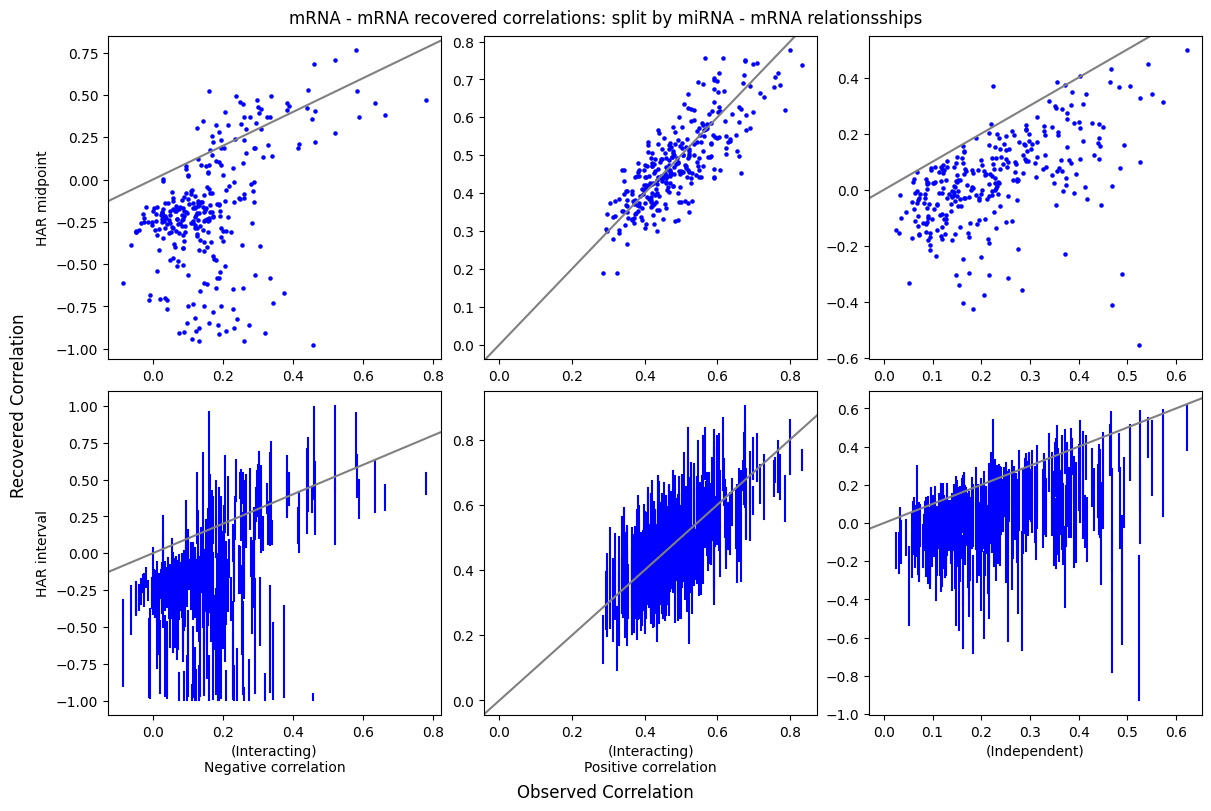

In [146]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
axs[0, 0].scatter(OB_neg[:, 0], HAR_mid_neg, s=5, color="blue")
axs[0, 1].scatter(OB_pos[:, 0], HAR_mid_pos, s=5, color="blue")
axs[0, 2].scatter(OB_ind[:, 0], HAR_mid_ind, s=5, color="blue")
axs[1, 0].plot([OB_neg[:, 0], OB_neg[:, 0]], [HAR_intervals_neg[:, 0], HAR_intervals_neg[:, 1]], color="blue");
axs[1, 1].plot([OB_pos[:, 0], OB_pos[:, 0]], [HAR_intervals_pos[:, 0], HAR_intervals_pos[:, 1]], color="blue");
axs[1, 2].plot([OB_ind[:, 0], OB_ind[:, 0]], [HAR_intervals_ind[:, 0], HAR_intervals_ind[:, 1]], color="blue");
for i in range(2):
    for j in range(3):
        axs[i, j].axline([0]*2, [0.1]*2, color="grey")
axs[0, 0].set_ylabel("HAR midpoint")
axs[1, 0].set_ylabel("HAR interval")
fig.supylabel("Recovered Correlation")
axs[1, 0].set_xlabel("(Interacting)\nNegative correlation")
axs[1, 1].set_xlabel("(Interacting)\nPositive correlation")
axs[1, 2].set_xlabel("(Independent)")
fig.supxlabel("Observed Correlation")
fig.suptitle("mRNA - mRNA recovered correlations: split by miRNA - mRNA relationsships")
plt.show()

# Appendix

## Estimate comparison: AL vs HAR midpoints

Broadly similar, especially for positive and independent mRNA (orange, green), some differences for negative mRNA (blue) where AL produces more extreme values

For mRNA - mRNA pairs with strong negative observed correlation AL breaks down and produces values below -1

Overall suggests HAR midpoint is a good single value to use

Text(0.5, 1.0, 'Correlation estimate comparison')

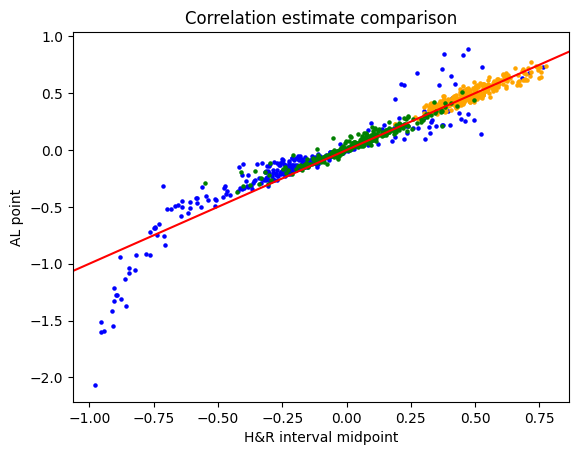

In [140]:
plt.scatter(HAR_mid_neg, AL_neg[:, 0], s=5, color="blue")
plt.scatter(HAR_mid_pos, AL_pos[:, 0], s=5, color="orange")
plt.scatter(HAR_mid_ind, AL_ind[:, 0], s=5, color="green")
plt.axline([0]*2, [0.1]*2, color="red")
plt.xlabel("H&R interval midpoint")
plt.ylabel("AL point")
plt.title("Correlation estimate comparison")

Text(0.5, 1.0, 'Correlation estimate comparison')

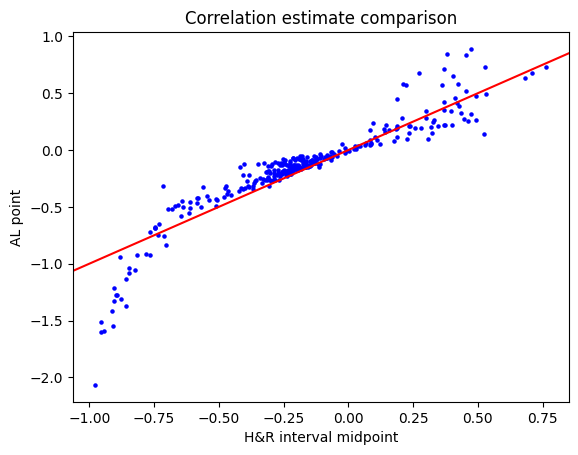

In [147]:
plt.scatter(HAR_mid_neg, AL_neg[:, 0], s=5, color="blue")
#plt.scatter(HAR_mid_pos, AL_pos[:, 0], s=5, color="orange")
#plt.scatter(HAR_mid_ind, AL_ind[:, 0], s=5, color="green")
plt.axline([0]*2, [0.1]*2, color="red")
plt.xlabel("H&R interval midpoint")
plt.ylabel("AL point")
plt.title("Correlation estimate comparison")